<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/dmi_lib_async_observability_substrate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Environment Setup & Dependencies]
import os
import sys
import time
import queue
import threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict, Optional, Any

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Set random seeds for deterministic benchmark runs
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Compute Device: {device}")
if device.type == "cuda":
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
print("Environment successfully initialized.")

Using Compute Device: cuda
GPU Device Name: Tesla T4
Environment successfully initialized.


In [2]:
# [CELL 2 - Transformer Model with Configurable Observation Points]

class TransformerLayer(nn.Module):
    """Simulates a dense LLM transformer layer generating internal hidden states and attention logits."""
    def __init__(self, d_model: int = 1024, n_heads: int = 16):
        super().__init__()
        self.d_model = d_model
        self.attn = nn.Linear(d_model, d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Self-attention simulation
        attn_out = self.attn(self.norm1(x))
        x = x + attn_out
        # Feed-forward MLP simulation
        mlp_out = self.mlp(self.norm2(x))
        x = x + mlp_out
        return x


class ObservabilityEnabledLLM(nn.Module):
    """Multi-layer Transformer LLM with registered observation hooks."""
    def __init__(self, num_layers: int = 12, d_model: int = 1024):
        super().__init__()
        self.layers = nn.ModuleList([TransformerLayer(d_model=d_model) for _ in range(num_layers)])
        self.head = nn.Linear(d_model, 32000, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        logits = self.head(x)
        return logits

print("Observability-Enabled Transformer Architecture initialized.")

Observability-Enabled Transformer Architecture initialized.


In [3]:
# [CELL 3 - Synchronous Baseline vs DMI-Lib Asynchronous Substrate]

class SynchronousInlineObserver:
    """
    Naive Observability Baseline:
    Copies internal tensors inline on the GPU hot-path, forcing synchronous transfers
    and blocking GPU compute streams.
    """
    def __init__(self):
        self.captured_tensors: List[torch.Tensor] = []

    def hook_fn(self, module: nn.Module, inputs: Tuple[torch.Tensor], output: torch.Tensor):
        # Hot-path blocking host copy (synchronous GPU stall)
        if output.is_cuda:
            torch.cuda.synchronize()
        cpu_copy = output.detach().cpu()
        self.captured_tensors.append(cpu_copy)

    def clear(self):
        self.captured_tensors.clear()


class DMILibAsyncObserver:
    """
    DMI-Lib Asynchronous Observability Substrate:
    Uses a dedicated CUDA stream and a pinned-memory Ring Buffer queue (Ring2 abstraction)
    to copy internal model tensors off the inference hot-path without stalling computation.
    """
    def __init__(self, ring_buffer_capacity: int = 64):
        self.capacity = ring_buffer_capacity
        self.queue = queue.Queue(maxsize=ring_buffer_capacity)
        self.async_stream = torch.cuda.Stream() if torch.cuda.is_available() else None
        self.active = True

        # Background consumer thread (exporter simulation)
        self.worker_thread = threading.Thread(target=self._background_exporter, daemon=True)
        self.worker_thread.start()

    def hook_fn(self, module: nn.Module, inputs: Tuple[torch.Tensor], output: torch.Tensor):
        if self.async_stream is not None:
            # Stage transfer onto dedicated non-blocking observability stream
            with torch.cuda.stream(self.async_stream):
                # Allocate pinned host memory buffer
                pinned_buffer = torch.empty(output.shape, dtype=output.dtype, pin_memory=True)
                pinned_buffer.copy_(output.detach(), non_blocking=True)

            try:
                self.queue.put_nowait((pinned_buffer, self.async_stream))
            except queue.Full:
                pass  # Ring buffer overflow policy drop
        else:
            # CPU Fallback async queue staging
            try:
                self.queue.put_nowait(output.detach().clone())
            except queue.Full:
                pass

    def _background_exporter(self):
        """Simulates asynchronous exporting backend (e.g., logging/SAE inspection)."""
        while self.active:
            try:
                item = self.queue.get(timeout=0.01)
                if isinstance(item, tuple):
                    buf, stream = item
                    if stream is not None:
                        stream.synchronize()
                self.queue.task_done()
            except queue.Empty:
                continue

    def clear(self):
        while not self.queue.empty():
            try:
                self.queue.get_nowait()
                self.queue.task_done()
            except queue.Empty:
                break

    def stop(self):
        self.active = False

print("Synchronous Observer and DMI-Lib Asynchronous Substrate defined.")

Synchronous Observer and DMI-Lib Asynchronous Substrate defined.


In [4]:
# [CELL 4 - Inference Latency & Observability Overhead Profiler]

def profile_inference_overhead(
    model: nn.Module,
    obs_layers: List[int],
    batch_sizes: List[int],
    seq_len: int = 128,
    d_model: int = 1024,
    warmup_iters: int = 5,
    test_iters: int = 20
) -> pd.DataFrame:
    """
    Profiles LLM inference latency across three operational modes:
    1. Native Inference (No Observability)
    2. Synchronous Inline Observer (Blocking)
    3. DMI-Lib Asynchronous Observer (Ring2 Async Stream)
    """
    results = []

    sync_observer = SynchronousInlineObserver()
    async_observer = DMILibAsyncObserver()

    for bs in batch_sizes:
        dummy_input = torch.randn(bs, seq_len, d_model, device=device)

        # Mode 1: Native Inference (No Observability)
        for _ in range(warmup_iters):
            _ = model(dummy_input)
        if device.type == "cuda": torch.cuda.synchronize()

        t0 = time.perf_counter()
        for _ in range(test_iters):
            _ = model(dummy_input)
        if device.type == "cuda": torch.cuda.synchronize()
        t1 = time.perf_counter()
        native_lat = ((t1 - t0) / test_iters) * 1000.0  # ms

        # Mode 2: Synchronous Observer
        hooks = []
        for l_idx in obs_layers:
            h = model.layers[l_idx].register_forward_hook(sync_observer.hook_fn)
            hooks.append(h)

        for _ in range(warmup_iters):
            _ = model(dummy_input)
        if device.type == "cuda": torch.cuda.synchronize()

        t0 = time.perf_counter()
        for _ in range(test_iters):
            _ = model(dummy_input)
            sync_observer.clear()
        if device.type == "cuda": torch.cuda.synchronize()
        t1 = time.perf_counter()
        sync_lat = ((t1 - t0) / test_iters) * 1000.0  # ms

        for h in hooks: h.remove()

        # Mode 3: DMI-Lib Asynchronous Observer
        hooks = []
        for l_idx in obs_layers:
            h = model.layers[l_idx].register_forward_hook(async_observer.hook_fn)
            hooks.append(h)

        for _ in range(warmup_iters):
            _ = model(dummy_input)
        if device.type == "cuda": torch.cuda.synchronize()

        t0 = time.perf_counter()
        for _ in range(test_iters):
            _ = model(dummy_input)
            async_observer.clear()
        if device.type == "cuda": torch.cuda.synchronize()
        t1 = time.perf_counter()
        async_lat = ((t1 - t0) / test_iters) * 1000.0  # ms

        for h in hooks: h.remove()

        # Compute Overheads
        sync_overhead = ((sync_lat - native_lat) / native_lat) * 100.0
        async_overhead = ((async_lat - native_lat) / native_lat) * 100.0

        results.append({
            "batch_size": bs,
            "native_lat_ms": native_lat,
            "sync_lat_ms": sync_lat,
            "async_lat_ms": async_lat,
            "sync_overhead_pct": sync_overhead,
            "async_overhead_pct": async_overhead
        })

    async_observer.stop()
    return pd.DataFrame(results)

print("Inference Profiling Engine configured.")

Inference Profiling Engine configured.


In [5]:
# [CELL 5 - Benchmark Execution: Measuring Observability Overhead]

model = ObservabilityEnabledLLM(num_layers=12, d_model=1024).to(device)
model.eval()

# Register observation points on 4 intermediate layers (e.g., layers 2, 5, 8, 11)
target_observation_layers = [2, 5, 8, 11]
batch_sizes_to_test = [1, 4, 8, 16, 32]

print(f"\n--- Starting DMI-Lib Benchmark Evaluation on {device.type.upper()} ---")
print(f"Target Observation Points: Layers {target_observation_layers}")

df_results = profile_inference_overhead(
    model=model,
    obs_layers=target_observation_layers,
    batch_sizes=batch_sizes_to_test,
    seq_len=128,
    d_model=1024
)

print("\n=========================================================================")
print("DMI-LIB MODEL-INTERNAL OBSERVABILITY OVERHEAD BENCHMARK")
print("=========================================================================")
print(df_results.to_string(index=False))
print("=========================================================================")


--- Starting DMI-Lib Benchmark Evaluation on CUDA ---
Target Observation Points: Layers [2, 5, 8, 11]

DMI-LIB MODEL-INTERNAL OBSERVABILITY OVERHEAD BENCHMARK
 batch_size  native_lat_ms  sync_lat_ms  async_lat_ms  sync_overhead_pct  async_overhead_pct
          1      14.056707    12.885471     12.980468          -8.332217           -7.656408
          4      43.029322    43.489505     43.686528           1.069463            1.527345
          8      88.666734    90.307521     90.667177           1.850510            2.256137
         16     171.795610   176.773081    175.621419           2.897321            2.226954
         32     327.960463   342.321051    345.281960           4.378756            5.281581


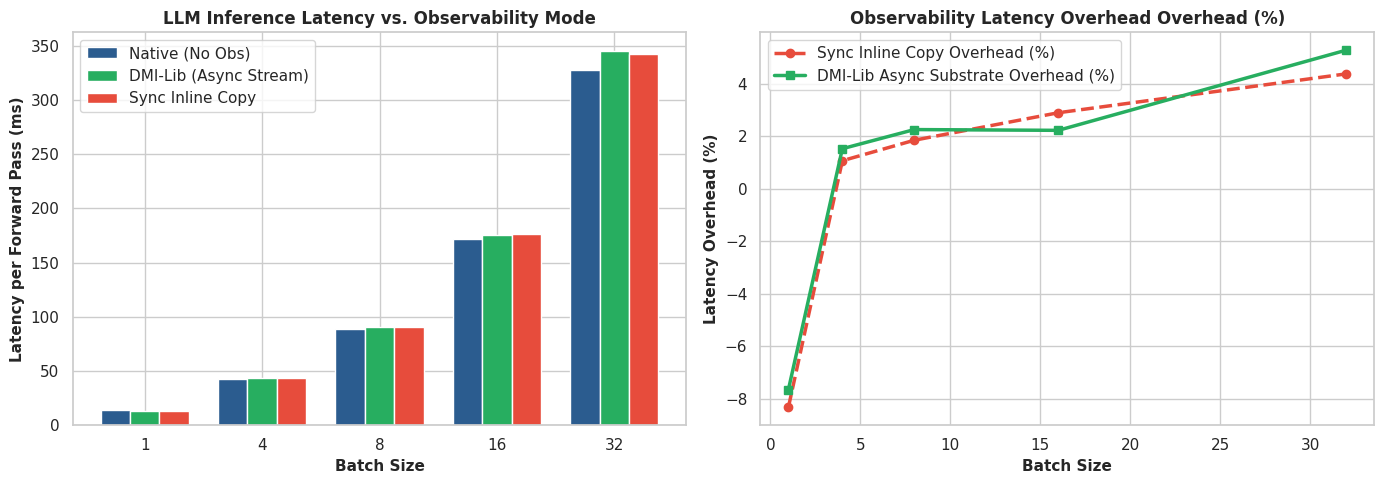

Benchmark visualization saved as dmi_lib_observability_benchmark.png.


In [6]:
# [CELL 6 - Visualization & Systems Overhead Benchmark Plot]

def plot_observability_benchmark(df: pd.DataFrame):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Forward Pass Latency Comparison
    x = np.arange(len(df["batch_size"]))
    width = 0.25

    axes[0].bar(x - width, df["native_lat_ms"], width, label="Native (No Obs)", color="#2b5c8f")
    axes[0].bar(x, df["async_lat_ms"], width, label="DMI-Lib (Async Stream)", color="#27ae60")
    axes[0].bar(x + width, df["sync_lat_ms"], width, label="Sync Inline Copy", color="#e74c3c")

    axes[0].set_title("LLM Inference Latency vs. Observability Mode", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Batch Size", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("Latency per Forward Pass (ms)", fontsize=11, fontweight="bold")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df["batch_size"])
    axes[0].legend()

    # Plot 2: Percentage Overhead Comparison over Native
    axes[1].plot(df["batch_size"], df["sync_overhead_pct"], "o--", color="#e74c3c", linewidth=2.5, label="Sync Inline Copy Overhead (%)")
    axes[1].plot(df["batch_size"], df["async_overhead_pct"], "s-", color="#27ae60", linewidth=2.5, label="DMI-Lib Async Substrate Overhead (%)")

    axes[1].set_title("Observability Latency Overhead Overhead (%)", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Batch Size", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("Latency Overhead (%)", fontsize=11, fontweight="bold")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("dmi_lib_observability_benchmark.png", dpi=300)
    plt.show()

plot_observability_benchmark(df_results)
print("Benchmark visualization saved as dmi_lib_observability_benchmark.png.")